# 1. Phase explorations - 2D

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection
import scienceplots

plt.style.use(["science","no-latex"])

## Columnar

### Vanilla Kuramoto - Edward-Wilkinson

In [3]:
typenoise = "Columnar"
L = 125
K = 40

deltaname = "0" # EW

path = f"../Simulations_2D/Output{typenoise}/all_simulations_delta{deltaname}.pkl"

df = pd.read_pickle(path)
df = df[(df["L"]==L) & (df["K"]==K)]
len(df)

109

In [4]:
simulation = df.iloc[1]
t = simulation["t"]
phases = simulation["phases"]

phases_2d = []
for ti in range(len(t)):
    phases_2d.append(phases[ti,:].reshape(L, L))
phases_2d = np.array(phases_2d)

In [6]:
phases.shape

(23, 15625)

In [4]:
t, phases_2d.shape

(array([0.00000000e+00, 1.00000050e+00, 1.60000080e+00, 2.56000128e+00,
        4.09000205e+00, 6.55000328e+00, 1.04800052e+01, 1.67700084e+01,
        2.68400134e+01, 4.29400215e+01, 6.87100344e+01, 1.09950055e+02,
        1.75920088e+02, 2.81470141e+02, 4.50350225e+02, 7.20570360e+02,
        1.15292058e+03, 1.84467092e+03, 2.95147148e+03, 4.72236236e+03,
        7.55578378e+03, 1.20892560e+04, 1.93428197e+04]),
 (23, 125, 125))

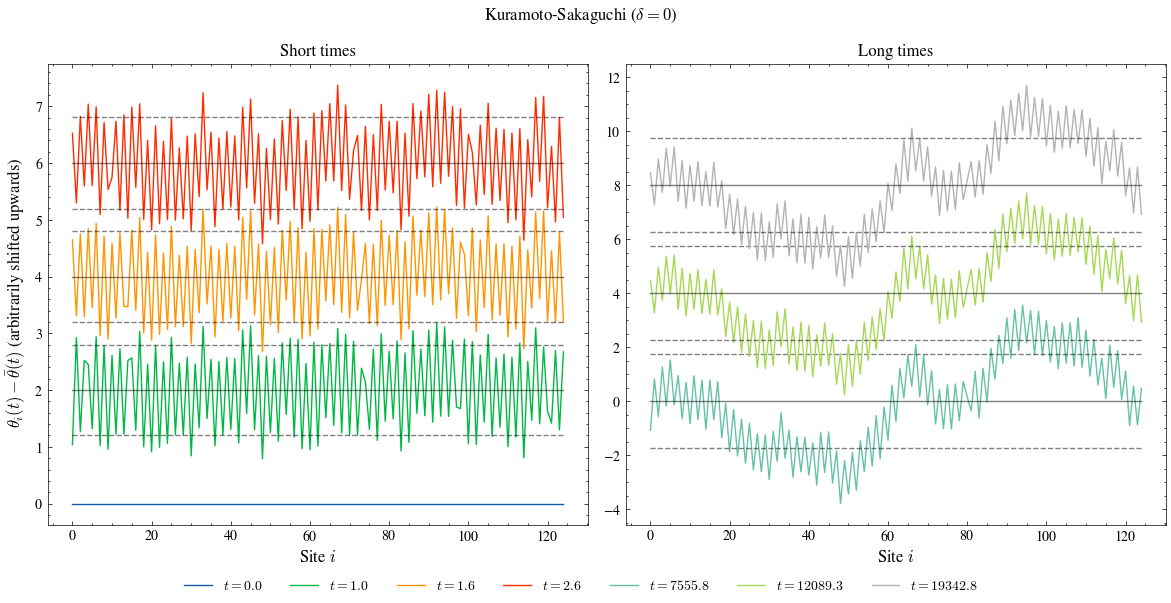

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))
fig.suptitle(r"Kuramoto-Sakaguchi ($\delta = 0$)")
fig.supylabel(r"$\theta_i(t) - \bar{\theta}(t)$ (arbitrarily shifted upwards)")
ax[0].set_xlabel(r"Site $i$", fontsize=12)
ax[1].set_xlabel(r"Site $i$", fontsize=12)

ax[0].set_title("Short times")
for ti, displace in zip([0,1,2,3], [0,2,4,6,8]):
    ax[0].plot(range(L), phases_2d[ti,0,:] + displace - np.mean(phases_2d[ti,0,:]),
               label=f"$t={np.round(t[ti],1)}$")
    if ti != 0:
        ax[0].plot(range(L), L * [displace], color="k", alpha=0.5)
        ax[0].plot(range(L), L * [np.std(phases_2d[ti,0,:]) + displace], color="k", linestyle="--", alpha=0.5)
        ax[0].plot(range(L), L * [-np.std(phases_2d[ti,0,:]) + displace], color="k", linestyle="--", alpha=0.5)

ax[1].set_title("Long times")
colors = plt.cm.Set2(np.linspace(0, 1, 3))  # different colors for subplot 2
for (ti, displace), c in zip(zip([20,21,22], [0,4,8]), colors):
    ax[1].plot(range(L), phases_2d[ti,0,:] + displace - np.mean(phases_2d[ti,0,:]),
               color=c, label=f"$t={np.round(t[ti],1)}$")
    if ti != 0:
        ax[1].plot(range(L), L * [displace], color="k", alpha=0.5)
        ax[1].plot(range(L), L * [np.std(phases_2d[ti,0,:]) + displace], color="k", linestyle="--", alpha=0.5)
        ax[1].plot(range(L), L * [-np.std(phases_2d[ti,0,:]) + displace], color="k", linestyle="--", alpha=0.5)

# one legend on the right (gather handles from both subplots)
h0, l0 = ax[0].get_legend_handles_labels()
h1, l1 = ax[1].get_legend_handles_labels()
fig.legend(h0 + h1, l0 + l1,
           loc="lower center",
           bbox_to_anchor=(0.5, -0.02),   # push below the figure
           ncol=len(l0 + l1),             # or choose e.g. ncol=4
           frameon=False)

# leave room at the bottom for the legend
plt.tight_layout(rect=[0, 0.02, 1, 1])     # increase 0.08 if needed
# plt.savefig("Figures/KuramotoPhases.png", dpi=300)

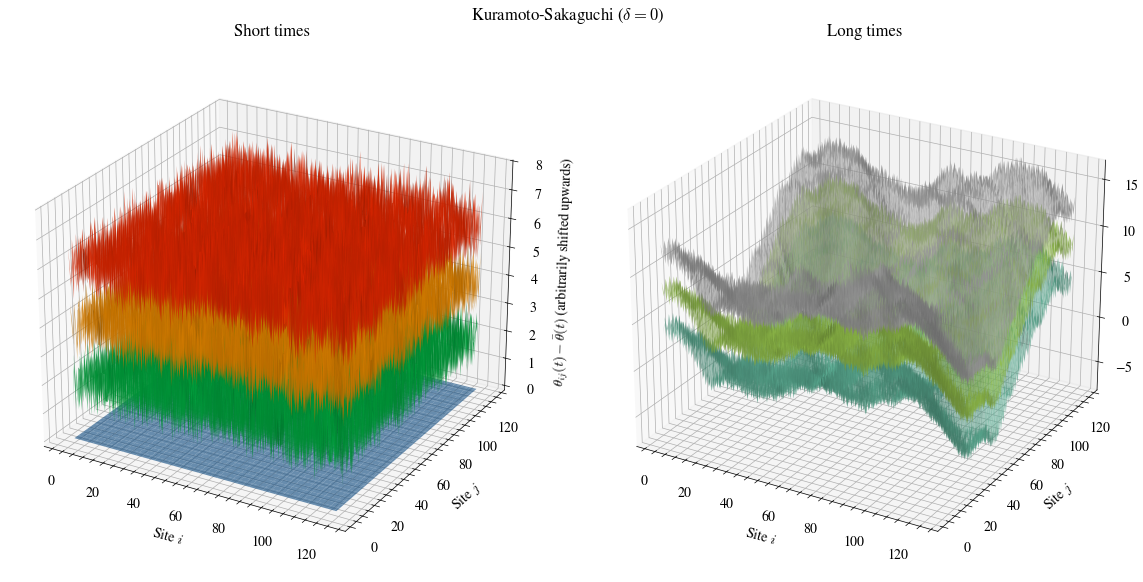

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={"projection": "3d"})
fig.suptitle(r"Kuramoto-Sakaguchi ($\delta = 0$)")

X, Y = np.meshgrid(range(L), range(L))

ax[0].set_title("Short times")
ax[0].set_xlabel(r"Site $i$")
ax[0].set_ylabel(r"Site $j$")
ax[0].set_zlabel(r"$\theta_{ij}(t) - \bar{\theta}(t)$ (arbitrarily shifted upwards)")

for ti, displace in zip([0,1,2,3], [0,2,4,6]):
    Z = phases_2d[ti] + displace - np.mean(phases_2d[ti])
    ax[0].plot_surface(X, Y, Z, alpha=0.6, label=f"$t={np.round(t[ti],1)}$")

ax[1].set_title("Long times")
ax[1].set_xlabel(r"Site $i$")
ax[1].set_ylabel(r"Site $j$")
ax[1].set_zlabel(r"$\theta_{ij}(t) - \bar{\theta}(t)$ (arbitrarily shifted upwards)")

colors = plt.cm.Set2(np.linspace(0, 1, 3))  # different colors for subplot 2
for (ti, displace), c in zip(zip([20,21,22], [0,4,8]), colors):
    Z = phases_2d[ti] + displace - np.mean(phases_2d[ti])
    ax[1].plot_surface(X, Y, Z, color=c, alpha=0.6)

ax[0].view_init(elev=25, azim=-60)
ax[1].view_init(elev=25, azim=-60)

plt.tight_layout()
# plt.savefig("Figures/KuramotoPhases_3D.png", dpi=300)
plt.show()

### Kuramoto-Sakaguchi - KPZ

In [9]:
typenoise = "Columnar"
L = 125
K = 40

deltaname = "atan5" # EW

path = f"Output{typenoise}/all_simulations_delta{deltaname}.pkl"

df = pd.read_pickle(path)
df = df[(df["L"]==L) & (df["K"]==K)]
len(df)

109

In [10]:
simulation = df.iloc[1]
t = simulation["t"]
phases = simulation["phases"]

phases_2d = []
for ti in range(len(t)):
    phases_2d.append(phases[ti,:].reshape(L, L))
phases_2d = np.array(phases_2d)

In [11]:
t, phases_2d.shape

(array([0.00000000e+00, 1.00000050e+00, 1.60000080e+00, 2.56000128e+00,
        4.09000205e+00, 6.55000328e+00, 1.04800052e+01, 1.67700084e+01,
        2.68400134e+01, 4.29400215e+01, 6.87100344e+01, 1.09950055e+02,
        1.75920088e+02, 2.81470141e+02, 4.50350225e+02, 7.20570360e+02,
        1.15292058e+03, 1.84467092e+03, 2.95147148e+03, 4.72236236e+03,
        7.55578378e+03, 1.20892560e+04, 1.93428197e+04]),
 (23, 125, 125))

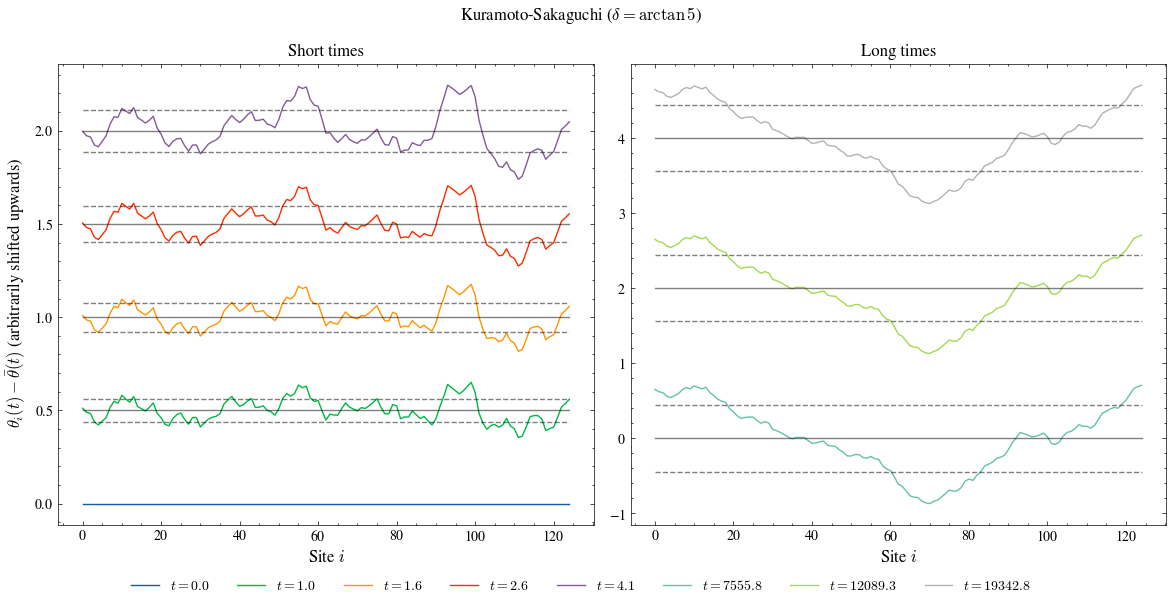

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))
fig.suptitle(r"Kuramoto-Sakaguchi ($\delta = \arctan 5 $)")
fig.supylabel(r"$\theta_i(t) - \bar{\theta}(t)$ (arbitrarily shifted upwards)")
ax[0].set_xlabel(r"Site $i$", fontsize=12)
ax[1].set_xlabel(r"Site $i$", fontsize=12)

ax[0].set_title("Short times")
for ti, displace in zip([0,1,2,3,4], [0,0.5,1,1.5,2]):
    ax[0].plot(range(L), phases_2d[ti,0,:] + displace - np.mean(phases_2d[ti,0,:]),
               label=f"$t={np.round(t[ti],1)}$")
    if ti != 0:
        ax[0].plot(range(L), L * [displace], color="k", alpha=0.5)
        ax[0].plot(range(L), L * [np.std(phases_2d[ti,0,:]) + displace], color="k", linestyle="--", alpha=0.5)
        ax[0].plot(range(L), L * [-np.std(phases_2d[ti,0,:]) + displace], color="k", linestyle="--", alpha=0.5)

ax[1].set_title("Long times")
colors = plt.cm.Set2(np.linspace(0, 1, 3))  # different colors for subplot 2
for (ti, displace), c in zip(zip([20,21,22], [0,2,4]), colors):
    ax[1].plot(range(L), phases_2d[ti,0,:] + displace - np.mean(phases_2d[ti,0,:]),
               color=c, label=f"$t={np.round(t[ti],1)}$")
    if ti != 0:
        ax[1].plot(range(L), L * [displace], color="k", alpha=0.5)
        ax[1].plot(range(L), L * [np.std(phases_2d[ti,0,:]) + displace], color="k", linestyle="--", alpha=0.5)
        ax[1].plot(range(L), L * [-np.std(phases_2d[ti,0,:]) + displace], color="k", linestyle="--", alpha=0.5)

# one legend on the right (gather handles from both subplots)
h0, l0 = ax[0].get_legend_handles_labels()
h1, l1 = ax[1].get_legend_handles_labels()
fig.legend(h0 + h1, l0 + l1,
           loc="lower center",
           bbox_to_anchor=(0.5, -0.02),   # push below the figure
           ncol=len(l0 + l1),             # or choose e.g. ncol=4
           frameon=False)

# leave room at the bottom for the legend
plt.tight_layout(rect=[0, 0.02, 1, 1])     # increase 0.08 if needed
# plt.savefig("Figures/KuramotoSakaguchiPhases.png", dpi=300)

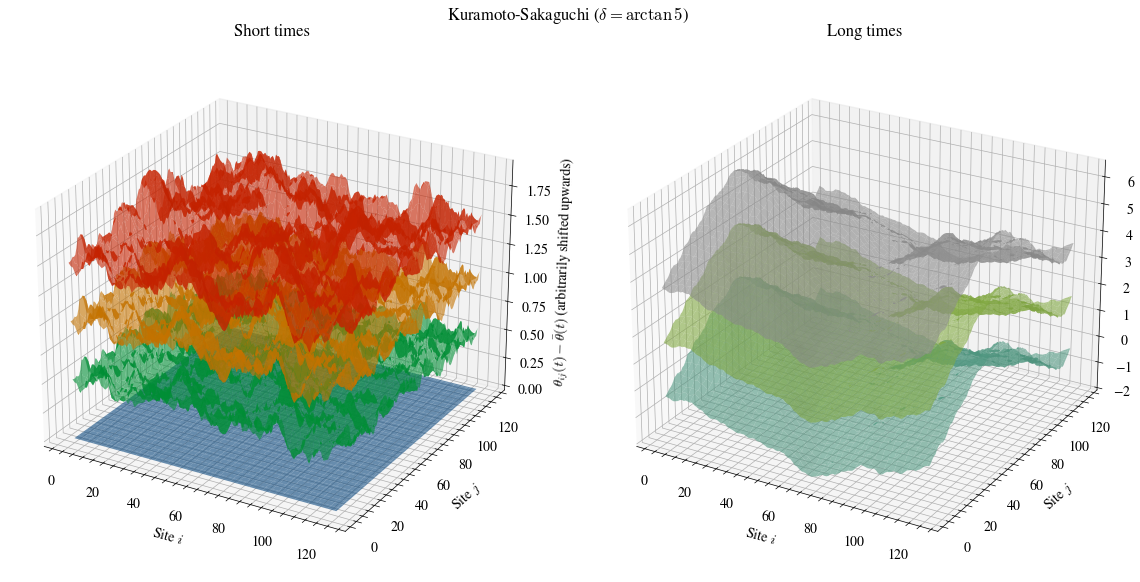

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={"projection": "3d"})
fig.suptitle(r"Kuramoto-Sakaguchi ($\delta = \arctan 5 $)")

X, Y = np.meshgrid(range(L), range(L))

ax[0].set_title("Short times")
ax[0].set_xlabel(r"Site $i$")
ax[0].set_ylabel(r"Site $j$")
ax[0].set_zlabel(r"$\theta_{ij}(t) - \bar{\theta}(t)$ (arbitrarily shifted upwards)")

for ti, displace in zip([0,1,2,3], [0,0.5,1,1.5,2]):
    Z = phases_2d[ti] + displace - np.mean(phases_2d[ti])
    ax[0].plot_surface(X, Y, Z, alpha=0.6, label=f"$t={np.round(t[ti],1)}$")

ax[1].set_title("Long times")
ax[1].set_xlabel(r"Site $i$")
ax[1].set_ylabel(r"Site $j$")
ax[1].set_zlabel(r"$\theta_{ij}(t) - \bar{\theta}(t)$ (arbitrarily shifted upwards)")

colors = plt.cm.Set2(np.linspace(0, 1, 3))  # different colors for subplot 2
for (ti, displace), c in zip(zip([20,21,22], [0,2,4]), colors):
    Z = phases_2d[ti] + displace - np.mean(phases_2d[ti])
    ax[1].plot_surface(X, Y, Z, color=c, alpha=0.6)

ax[0].view_init(elev=25, azim=-60)
ax[1].view_init(elev=25, azim=-60)

plt.tight_layout()
# plt.savefig("Figures/KuramotoPhases_3D.png", dpi=300)
plt.show()

## Time-dependent

### Vanilla Kuramoto - Edward-Wilkinson

In [14]:
typenoise = "TimeDep"
L = 125
K = 1

deltaname = "0" # EW

path = f"Output{typenoise}/all_simulations_delta{deltaname}.pkl"

df = pd.read_pickle(path)
df = df[(df["L"]==L) & (df["K"]==K)]
len(df)

103

In [15]:
simulation = df.iloc[1]
t = simulation["t"]
phases = simulation["phases"]

phases_2d = []
for ti in range(len(t)):
    phases_2d.append(phases[ti,:].reshape(L, L))
phases_2d = np.array(phases_2d)

In [16]:
t, phases_2d.shape

(array([0.00000000e+00, 1.00000050e+00, 1.60000080e+00, 2.56000128e+00,
        4.09000205e+00, 6.55000328e+00, 1.04800052e+01, 1.67700084e+01,
        2.68400134e+01, 4.29400215e+01, 6.87100344e+01, 1.09950055e+02,
        1.75920088e+02, 2.81470141e+02, 4.50350225e+02, 7.20570360e+02,
        1.15292058e+03, 1.84467092e+03, 2.95147148e+03, 4.72236236e+03,
        7.55578378e+03, 1.20892560e+04, 1.93428197e+04]),
 (23, 125, 125))

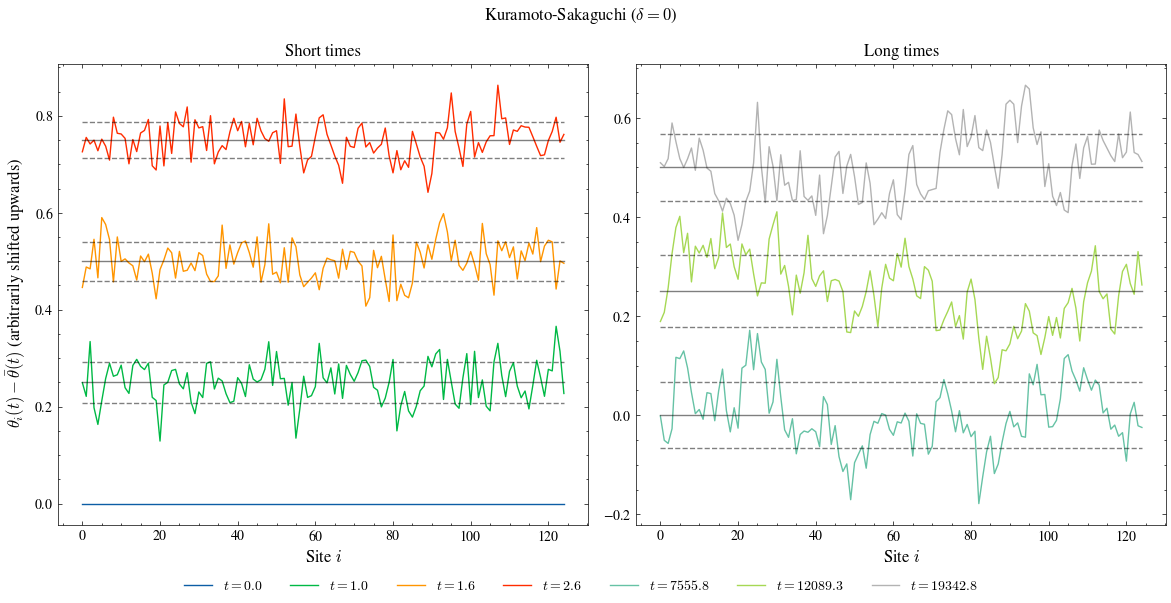

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))
fig.suptitle(r"Kuramoto-Sakaguchi ($\delta = 0$)")
fig.supylabel(r"$\theta_i(t) - \bar{\theta}(t)$ (arbitrarily shifted upwards)")
ax[0].set_xlabel(r"Site $i$", fontsize=12)
ax[1].set_xlabel(r"Site $i$", fontsize=12)

ax[0].set_title("Short times")
for ti, displace in zip([0,1,2,3], [0,0.25,0.5,0.75]):
    ax[0].plot(range(L), phases_2d[ti,0,:] + displace - np.mean(phases_2d[ti,0,:]),
               label=f"$t={np.round(t[ti],1)}$")
    if ti != 0:
        ax[0].plot(range(L), L * [displace], color="k", alpha=0.5)
        ax[0].plot(range(L), L * [np.std(phases_2d[ti,0,:]) + displace], color="k", linestyle="--", alpha=0.5)
        ax[0].plot(range(L), L * [-np.std(phases_2d[ti,0,:]) + displace], color="k", linestyle="--", alpha=0.5)

ax[1].set_title("Long times")
colors = plt.cm.Set2(np.linspace(0, 1, 3))  # different colors for subplot 2
for (ti, displace), c in zip(zip([20,21,22], [0,0.25,0.5]), colors):
    ax[1].plot(range(L), phases_2d[ti,0,:] + displace - np.mean(phases_2d[ti,0,:]),
               color=c, label=f"$t={np.round(t[ti],1)}$")
    if ti != 0:
        ax[1].plot(range(L), L * [displace], color="k", alpha=0.5)
        ax[1].plot(range(L), L * [np.std(phases_2d[ti,0,:]) + displace], color="k", linestyle="--", alpha=0.5)
        ax[1].plot(range(L), L * [-np.std(phases_2d[ti,0,:]) + displace], color="k", linestyle="--", alpha=0.5)

# one legend on the right (gather handles from both subplots)
h0, l0 = ax[0].get_legend_handles_labels()
h1, l1 = ax[1].get_legend_handles_labels()
fig.legend(h0 + h1, l0 + l1,
           loc="lower center",
           bbox_to_anchor=(0.5, -0.02),   # push below the figure
           ncol=len(l0 + l1),             # or choose e.g. ncol=4
           frameon=False)

# leave room at the bottom for the legend
plt.tight_layout(rect=[0, 0.02, 1, 1])     # increase 0.08 if needed
# plt.savefig("Figures/KuramotoPhases.png", dpi=300)

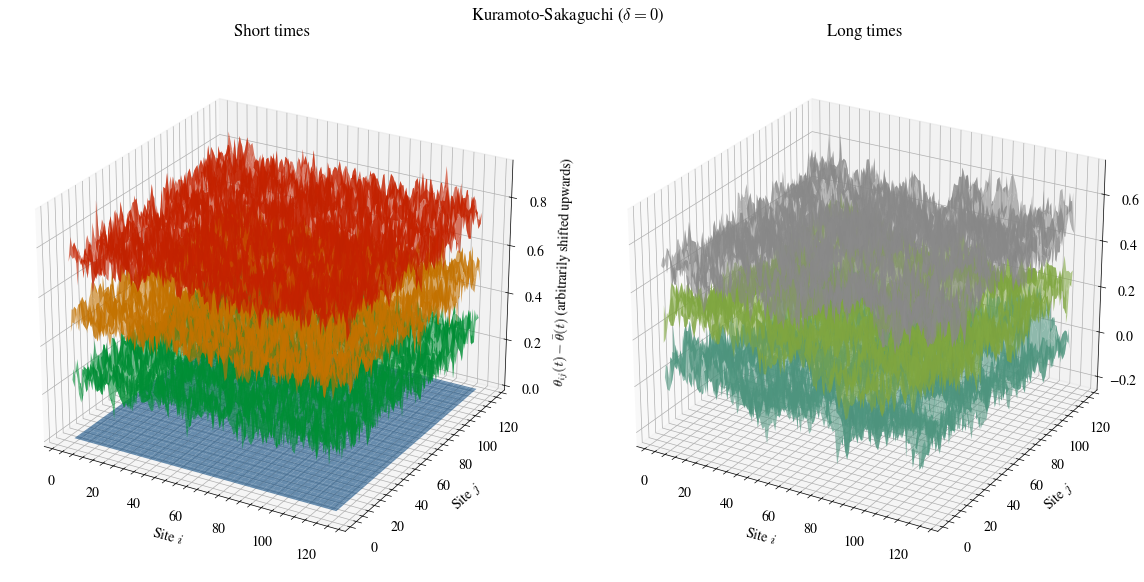

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={"projection": "3d"})
fig.suptitle(r"Kuramoto-Sakaguchi ($\delta = 0$)")

X, Y = np.meshgrid(range(L), range(L))

ax[0].set_title("Short times")
ax[0].set_xlabel(r"Site $i$")
ax[0].set_ylabel(r"Site $j$")
ax[0].set_zlabel(r"$\theta_{ij}(t) - \bar{\theta}(t)$ (arbitrarily shifted upwards)")

for ti, displace in zip([0,1,2,3], [0,0.25,0.5,0.75]):
    Z = phases_2d[ti] + displace - np.mean(phases_2d[ti])
    ax[0].plot_surface(X, Y, Z, alpha=0.6, label=f"$t={np.round(t[ti],1)}$")

ax[1].set_title("Long times")
ax[1].set_xlabel(r"Site $i$")
ax[1].set_ylabel(r"Site $j$")
ax[1].set_zlabel(r"$\theta_{ij}(t) - \bar{\theta}(t)$ (arbitrarily shifted upwards)")

colors = plt.cm.Set2(np.linspace(0, 1, 3))  # different colors for subplot 2
for (ti, displace), c in zip(zip([20,21,22], [0,0.25,0.5]), colors):
    Z = phases_2d[ti] + displace - np.mean(phases_2d[ti])
    ax[1].plot_surface(X, Y, Z, color=c, alpha=0.6)

ax[0].view_init(elev=25, azim=-60)
ax[1].view_init(elev=25, azim=-60)

plt.tight_layout()
# plt.savefig("Figures/KuramotoPhases_3D.png", dpi=300)
plt.show()

### Kuramoto-Sakaguchi - KPZ

In [31]:
typenoise = "TimeDep"
L = 125
K = 1

deltaname = "atan5" # EW

path = f"Output{typenoise}/all_simulations_delta{deltaname}.pkl"

df = pd.read_pickle(path)
df = df[(df["L"]==L) & (df["K"]==K)]
len(df)

52

In [32]:
simulation = df.iloc[1]
t = simulation["t"]
phases = simulation["phases"]

phases_2d = []
for ti in range(len(t)):
    phases_2d.append(phases[ti,:].reshape(L, L))
phases_2d = np.array(phases_2d)

In [33]:
t, phases_2d.shape

(array([0.00000000e+00, 1.00000050e+00, 1.60000080e+00, 2.56000128e+00,
        4.09000205e+00, 6.55000328e+00, 1.04800052e+01, 1.67700084e+01,
        2.68400134e+01, 4.29400215e+01, 6.87100344e+01, 1.09950055e+02,
        1.75920088e+02, 2.81470141e+02, 4.50350225e+02, 7.20570360e+02,
        1.15292058e+03, 1.84467092e+03, 2.95147148e+03, 4.72236236e+03,
        7.55578378e+03, 1.20892560e+04, 1.93428197e+04]),
 (23, 125, 125))

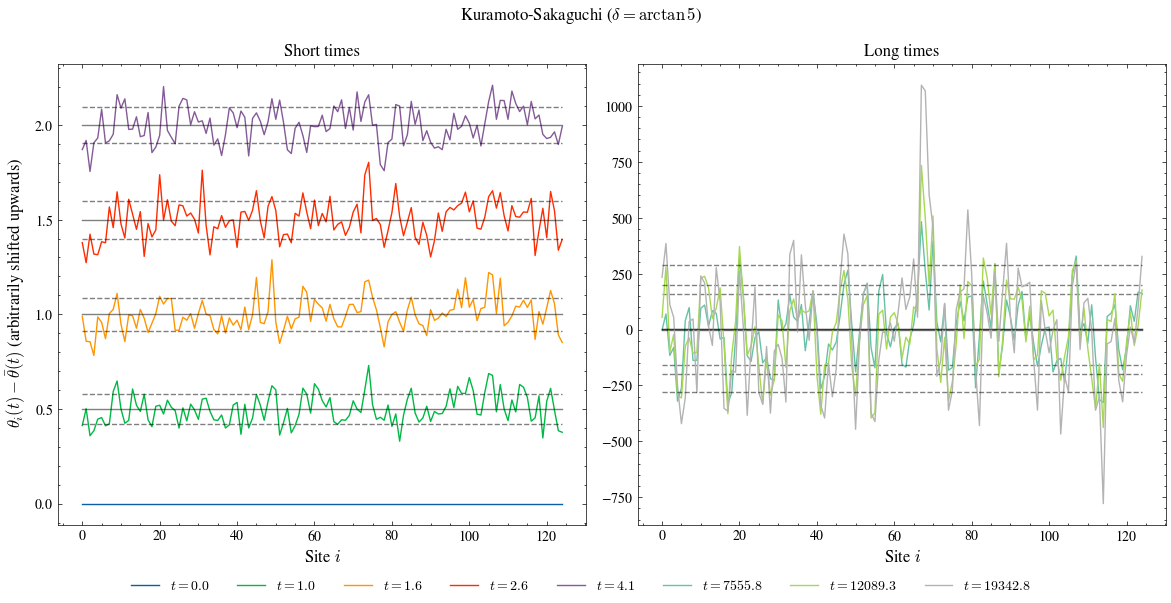

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))
fig.suptitle(r"Kuramoto-Sakaguchi ($\delta = \arctan 5 $)")
fig.supylabel(r"$\theta_i(t) - \bar{\theta}(t)$ (arbitrarily shifted upwards)")
ax[0].set_xlabel(r"Site $i$", fontsize=12)
ax[1].set_xlabel(r"Site $i$", fontsize=12)

ax[0].set_title("Short times")
for ti, displace in zip([0,1,2,3], [0,0.5,1,1.5]):
    ax[0].plot(range(L), phases_2d[ti,0,:] + displace - np.mean(phases_2d[ti,0,:]),
               label=f"$t={np.round(t[ti],1)}$")
    if ti != 0:
        ax[0].plot(range(L), L * [displace], color="k", alpha=0.5)
        ax[0].plot(range(L), L * [np.std(phases_2d[ti,0,:]) + displace], color="k", linestyle="--", alpha=0.5)
        ax[0].plot(range(L), L * [-np.std(phases_2d[ti,0,:]) + displace], color="k", linestyle="--", alpha=0.5)

ax[1].set_title("Long times")
colors = plt.cm.Set2(np.linspace(0, 1, 3))  # different colors for subplot 2
for ti, displace, c in zip([20,21,22], [0,2,4], colors):
    ax[1].plot(range(L), phases_2d[ti,0,:] + displace - np.mean(phases_2d[ti,0,:]),
               color=c, label=f"$t={np.round(t[ti],1)}$")
    if ti != 0:
        ax[1].plot(range(L), L * [displace], color="k", alpha=0.5)
        ax[1].plot(range(L), L * [np.std(phases_2d[ti,0,:]) + displace], color="k", linestyle="--", alpha=0.5)
        ax[1].plot(range(L), L * [-np.std(phases_2d[ti,0,:]) + displace], color="k", linestyle="--", alpha=0.5)

# one legend on the right (gather handles from both subplots)
h0, l0 = ax[0].get_legend_handles_labels()
h1, l1 = ax[1].get_legend_handles_labels()
fig.legend(h0 + h1, l0 + l1,
           loc="lower center",
           bbox_to_anchor=(0.5, -0.02),   # push below the figure
           ncol=len(l0 + l1),             # or choose e.g. ncol=4
           frameon=False)

# leave room at the bottom for the legend
plt.tight_layout(rect=[0, 0.02, 1, 1])     # increase 0.08 if needed
# plt.savefig("Figures/KuramotoSakaguchiPhases.png", dpi=300)

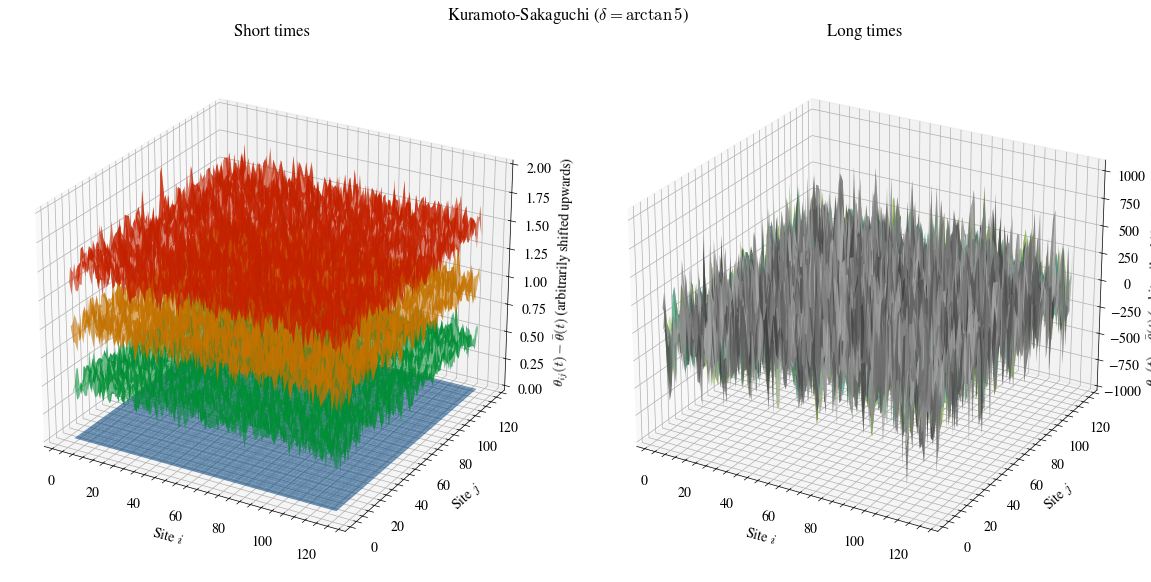

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={"projection": "3d"})
fig.suptitle(r"Kuramoto-Sakaguchi ($\delta = \arctan 5 $)")

X, Y = np.meshgrid(range(L), range(L))

ax[0].set_title("Short times")
ax[0].set_xlabel(r"Site $i$")
ax[0].set_ylabel(r"Site $j$")
ax[0].set_zlabel(r"$\theta_{ij}(t) - \bar{\theta}(t)$ (arbitrarily shifted upwards)")

for ti, displace in zip([0,1,2,3], [0,0.5,1,1.5]):
    Z = phases_2d[ti] + displace - np.mean(phases_2d[ti])
    ax[0].plot_surface(X, Y, Z, alpha=0.6, label=f"$t={np.round(t[ti],1)}$")

ax[1].set_title("Long times")
ax[1].set_xlabel(r"Site $i$")
ax[1].set_ylabel(r"Site $j$")
ax[1].set_zlabel(r"$\theta_{ij}(t) - \bar{\theta}(t)$ (arbitrarily shifted upwards)")

colors = plt.cm.Set2(np.linspace(0, 1, 3))  # different colors for subplot 2
for (ti, displace), c in zip(zip([20,21,22], [0,2,4]), colors):
    Z = phases_2d[ti] + displace - np.mean(phases_2d[ti])
    ax[1].plot_surface(X, Y, Z, color=c, alpha=0.6)

ax[0].view_init(elev=25, azim=-60)
ax[1].view_init(elev=25, azim=-60)

plt.tight_layout()
# plt.savefig("Figures/KuramotoPhases_3D.png", dpi=300)
plt.show()